In [1]:
# Problem: Predicting airline passenger satisfaction with Gradient Boosting Machine (GBM)
# It is a binary classification type problem.


import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [4]:
# Step 1: Load the data
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')



In [5]:
# Step 2: Preprocess the training and test data
train_data = train_data.dropna()
test_data = test_data.dropna()

# Ensure both dataset have same target value for consistency.
X_train = train_data.drop('satisfaction', axis=1) # Feature
y_train = train_data['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0}) # Target Value

X_val = test_data.drop('satisfaction', axis=1)
y_val = test_data['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

# Use on-hot encoding to convert categorical features to their respective columns
# that machine learning algorithm can understand.
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)


In [6]:
# Step 3: Build and Train the model.
# When you set random_state to a specific number (like 42), it ensures that the results are consistent every time you run the code
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [7]:
# Step 4: Make Predictions and Evaluate
predictions = model.predict(X_val)
accuracy_score = accuracy_score(y_val, predictions)
print("Accuracy Score:\n", accuracy_score)
confusion_matrix = confusion_matrix(y_val, predictions)
print("Confusion Matrix:\n", confusion_matrix)
classification_report = classification_report(y_val, predictions)
print("Classification Report:\n", classification_report)

Accuracy Score:
 0.9418375622755185
Confusion Matrix:
 [[13919   609]
 [  897 10468]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95     14528
           1       0.95      0.92      0.93     11365

    accuracy                           0.94     25893
   macro avg       0.94      0.94      0.94     25893
weighted avg       0.94      0.94      0.94     25893



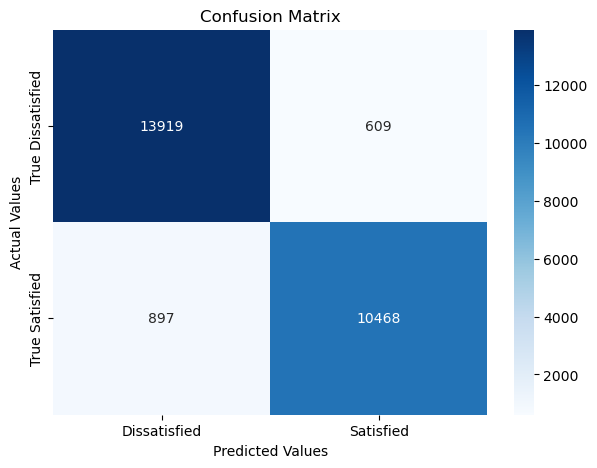

In [9]:
# Step 5: Visualization
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Dissatisfied', 'Satisfied'], yticklabels=['True Dissatisfied', 'True Satisfied'])
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix')
plt.show()

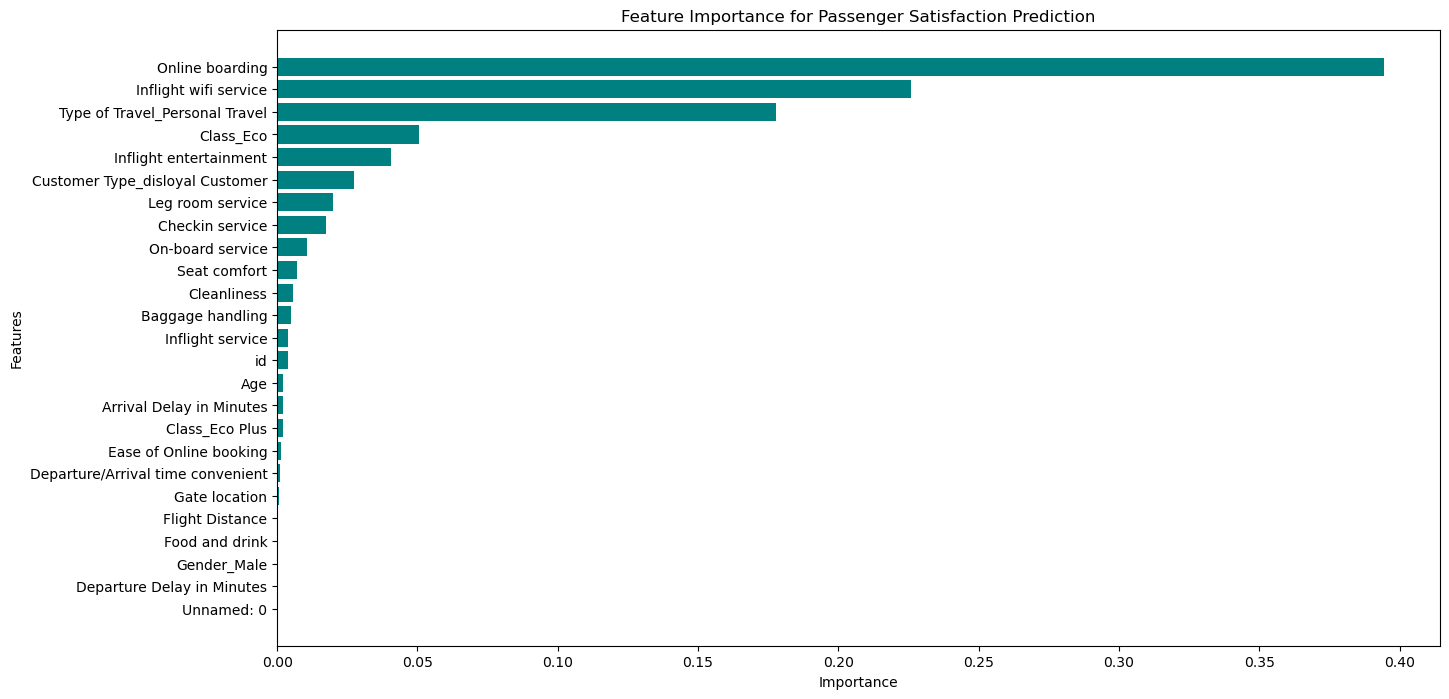

In [10]:
# Feature Importance Visualization
# In machine learning models like Gradient Boosting, feature importance helps us understand which features (variables)
# have the biggest impact on the model's predictions. This can help you see which attributes, like age,
# flight distance, or type of travel, are most critical in predicting passenger satisfaction.
feature_importance = model.feature_importances_
sorted_indx = np.argsort(feature_importance)
plt.figure(figsize=(15,8))
plt.barh(X_train.columns[sorted_indx], feature_importance[sorted_indx], color='teal')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance for Passenger Satisfaction Prediction')
plt.show()